# Pipeline Explanation

This notebook evaluates the robustness of Named Entity Recognition (NER) models when applied to translated text using spaCy language models. The pipeline involves the following steps:

1. **Data Loading**: Load the translated dataset containing original and translated article titles in various languages.
2. **Text Cleaning**: Preprocess the titles by converting to lowercase and removing unwanted elements like parentheses.
3. **Model Setup**: Define language-specific spaCy models for multilingual NER and load an English model for translated titles.
4. **NER Extraction**: Apply NER to both original titles (using language-specific models) and translated titles (using English model) to extract entity labels.
5. **Similarity Calculation**: Compute Jaccard similarity based on label counts between original and translated NER outputs.
6. **Analysis and Visualization**: Aggregate results by language, compute mean similarities, and visualize label count comparisons.
7. **Output Summary**: Display and plot the results for analysis.

This pipeline is used to assess how well NER models maintain performance across translations, which is important for multilingual NLP applications where text may be translated before entity extraction.

In [1]:
# Import and Set up
import pandas as pd
import spacy
import re
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# Load the dataset
media_cloud = pd.read_csv(
    "../data/mediacloud-translated-completed_taba.csv",
    encoding="utf-8"
)

print("Dataset shape:", media_cloud.shape)
print("Languages:", media_cloud['language'].value_counts())


Dataset shape: (44845, 10)
Languages: language
es    22494
pt    12068
tr     3085
it     2138
fr     1663
uk      850
ru      819
nl      804
de      766
pl      158
Name: count, dtype: int64


In [3]:
# Text cleaning function

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'\([^)]*\)', '', text)  # remove parentheses
    return text.strip()

media_cloud['clean_title'] = media_cloud['title'].apply(clean_text)
media_cloud['clean_translated_title'] = media_cloud['translated_title'].apply(clean_text)


In [4]:
# Load spaCy language models
LANGUAGE_MODELS = {
    "es": "es_core_news_lg",
    "pt": "pt_core_news_lg",
    "it": "it_core_news_lg",
    "fr": "fr_core_news_lg",
    "uk": "uk_core_news_lg",
    "ru": "ru_core_news_lg",
    "nl": "nl_core_news_lg",
    "de": "de_core_news_lg",
    "pl": "pl_core_news_lg"
}


In [5]:
# Lazy SpaCy model loader

loaded_models = {}

def get_nlp_model(lang):
    if lang not in LANGUAGE_MODELS:
        return None

    if lang not in loaded_models:
        model_name = LANGUAGE_MODELS[lang]
        try:
            loaded_models[lang] = spacy.load(model_name)
            print(f"Loaded {model_name}")
        except OSError:
            print(f"Installing {model_name}...")
            !python -m spacy download {model_name}
            loaded_models[lang] = spacy.load(model_name)

    return loaded_models[lang]


In [6]:
# NER Label Extraction (ORIGINAL TITLES)

def extract_ner_labels_multilingual(text, lang):
    if text.strip() == "":
        return []

    nlp = get_nlp_model(lang)
    if nlp is None:
        return []

    doc = nlp(text)
    return [ent.label_ for ent in doc.ents]

media_cloud['labels_original'] = media_cloud.apply(
    lambda row: extract_ner_labels_multilingual(
        row['clean_title'], row['language']
    ),
    axis=1
)


Loaded es_core_news_lg
Loaded ru_core_news_lg
Loaded fr_core_news_lg
Loaded de_core_news_lg
Loaded it_core_news_lg
Loaded uk_core_news_lg
Loaded nl_core_news_lg
Loaded pl_core_news_lg
Loaded pt_core_news_lg


In [7]:
# NER Lable Extraction (TRANSLATED TITLES)
try:
    nlp_en = spacy.load("en_core_web_lg")
except OSError:
    !python -m spacy download en_core_web_lg
    nlp_en = spacy.load("en_core_web_lg")

def extract_ner_labels_english(text):
    if text.strip() == "":
        return []
    doc = nlp_en(text)
    return [ent.label_ for ent in doc.ents]

media_cloud['labels_translated'] = media_cloud['clean_translated_title'].apply(
    extract_ner_labels_english
)


In [8]:
# Label Count Jaccard Similarity

def label_count_jaccard(labels_orig, labels_trans):
    c1 = Counter(labels_orig)
    c2 = Counter(labels_trans)

    labels = set(c1) | set(c2)
    intersection = sum(min(c1[l], c2[l]) for l in labels)
    union = sum(max(c1[l], c2[l]) for l in labels)

    return intersection / union if union > 0 else 1.0

media_cloud['label_jaccard'] = media_cloud.apply(
    lambda row: label_count_jaccard(
        row['labels_original'], row['labels_translated']
    ),
    axis=1
)



In [9]:
# Aggregate and summarize results

robustness_summary = (
    media_cloud
    .groupby('language')
    .agg(
        label_jaccard_mean=('label_jaccard', 'mean'),
        label_jaccard_std=('label_jaccard', 'std'),
        n_samples=('label_jaccard', 'count')
    )
    .reset_index()
)

# Exclude Turkish (no spaCy model)
robustness_summary = robustness_summary[
    robustness_summary['language'] != 'tr'
]

print("\n=== LABEL-COUNT TRANSLATION ROBUSTNESS SUMMARY ===")
print(robustness_summary.round(3))



=== LABEL-COUNT TRANSLATION ROBUSTNESS SUMMARY ===
  language  label_jaccard_mean  label_jaccard_std  n_samples
0       de               0.231              0.370        766
1       es               0.298              0.436      22494
2       fr               0.378              0.467       1663
3       it               0.245              0.400       2138
4       nl               0.533              0.448        804
5       pl               0.456              0.500        158
6       pt               0.258              0.421      12068
7       ru               0.247              0.413        819
9       uk               0.269              0.415        850


In [10]:
# Prepare data for plotting
def expand_label_counts(label_lists):
    counter = Counter()
    for labels in label_lists:
        counter.update(labels)
    return counter

plot_data = []

for lang in robustness_summary['language']:
    subset = media_cloud[media_cloud['language'] == lang]

    orig_counts = expand_label_counts(subset['labels_original'])
    trans_counts = expand_label_counts(subset['labels_translated'])

    for label in set(orig_counts) | set(trans_counts):
        plot_data.append({
            "language": lang,
            "label": label,
            "count": orig_counts.get(label, 0),
            "source": "Original"
        })
        plot_data.append({
            "language": lang,
            "label": label,
            "count": trans_counts.get(label, 0),
            "source": "Translated"
        })

plot_df = pd.DataFrame(plot_data)


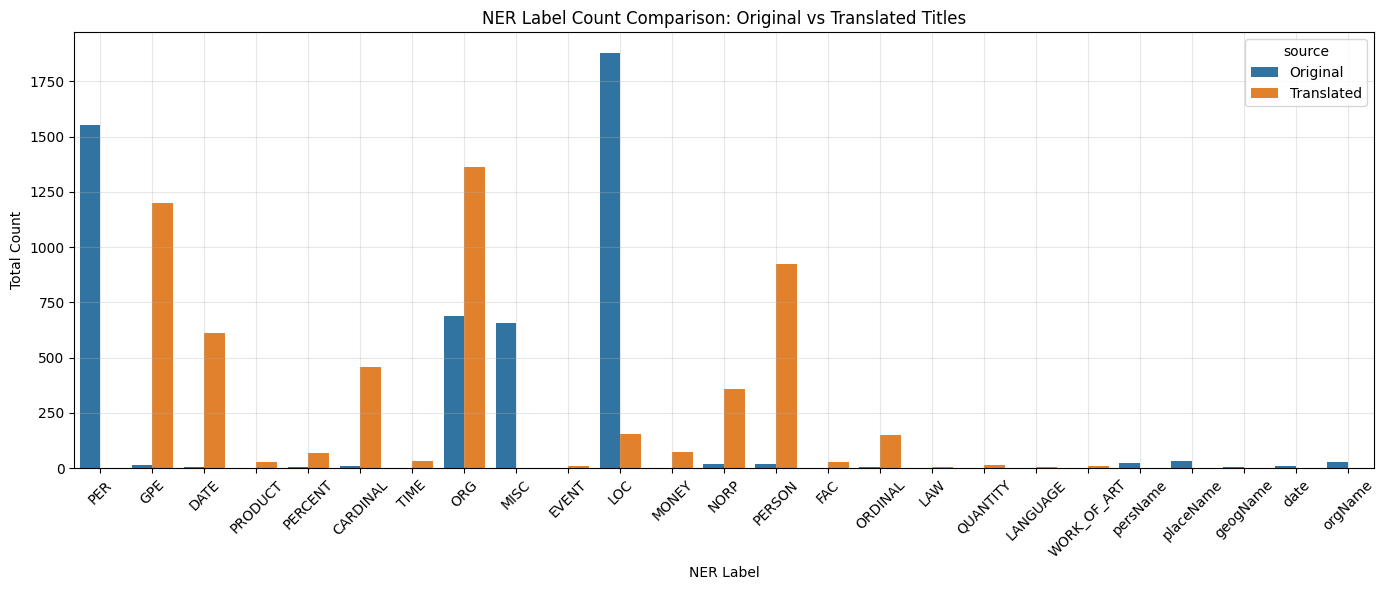

In [11]:
# Plot Original vs Translated NER Label Counts

plt.figure(figsize=(14, 6))
sns.barplot(
    data=plot_df,
    x="label",
    y="count",
    hue="source",
    errorbar=None
)

plt.title("NER Label Count Comparison: Original vs Translated Titles")
plt.xlabel("NER Label")
plt.ylabel("Total Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
